Consider a system of $N$ populations, whose state and external input are described by $N$-dimensional vectors $\bar{r}$ and $\bar{h}$, respectively.

A population recieves recurrent inputs from all populations (including itself) and an external input. \
Let's denote the input-output relation for the $n$-th population as $f_n$:
$$
r_n^{out} = f_n(\bar{r}^{in}, h_n)
$$

In vectorized form:
$$
\bar{r}^{out} = F(\bar{r}^{in}, \bar{h}), \\
F = (f_1, ... , f_n)
$$

Let's implement $F$ for a simple Wilson-Cowan-like model:
$$
\bar{r}^{out} = g(W \bar{r}^{in} + \bar{h}),
$$
where $W$ is an $N \times N$ weight matrix, and $g$ is a gain function (applied element-wise):
$$
g(x) = A / [1 + \exp(-k(x - x_c))]
$$

In [2]:
import numpy as np
import pandas as pd


# Gain function
def g(x, gpar):
    return gpar['A'] / (1 + np.exp(-gpar['k'] * (x - gpar['xc'])))

# F: (r_in, h) -> r_out (vectorized)
def F(r_in, h, W, gpar) -> np.ndarray:
    return g(W @ r_in + h, gpar)

# fpop: (r_in, h) -> r_out (single population)
def fpop(r_in, h, pop_num, W, gpar) -> float:
    return g(W[pop_num, :] @ r_in + h[pop_num], gpar).item()

# Set the parameters
N = 5  # Number of populations
gpar = {'A': 10, 'k': 0.5, 'xc': 0} # Gain parameters
W = 0.2 * np.random.randn(N, N)  # Weight matrix

# Inputs
r_in = 10 * np.abs(np.random.rand(N, 1))  # Input pop. rates
h = 1 * np.random.randn(N, 1)  # Exernal inputs

# Output firing rates (vectorized)
r_out = F(r_in, h, W, gpar)

# Print the result
df = pd.DataFrame(
    {'r_in': r_in.ravel(), 'h': h.ravel(), 'r_out': r_out.ravel()}
)
print(df.round(2))

# Test fpop
pop_num = 2
r_out_single = fpop(r_in, h, pop_num, W, gpar)
print(f'\nfpop: {r_out_single:.2f}')
print(f'F: {r_out[pop_num].item():.2f}')


   r_in     h  r_out
0  4.91  0.18   2.88
1  5.80  0.69   9.91
2  0.22 -0.62   5.56
3  7.86  1.05   3.07
4  6.87 -0.04   7.07

fpop: 5.56
F: 5.56


In a steady state, $\bar{r}$ should satisfy the self-consistency condition:
$$
\bar{r} = F(\bar{r}, \bar{h})
$$

Let's define a function $S: \bar{h} \rightarrow \bar{r}$ that **maps an external input $\bar{h}$ to the corresponding solution** $\bar{r}$ of the  above equation. In other words:
$$
S(\bar{h}) = F(S(\bar{h}), \bar{h})
$$

To implement $S$, we can take an initial guess $\bar{r}=\bar{r}_{start}$ and recursively apply $F$ to it several times. For better convergence, we can introduce a factor $\alpha$ that defines how much the curent guess changes at each iteration.

In [3]:
def S(r_start, h, W, gpar, n_iter=10, alpha=0.5):
    r = r_start
    for n in range(n_iter):
        rnew = F(r, h, W, gpar)
        r = alpha * rnew + (1 - alpha) * r
    return r

Let's choose an external input $\bar{h}_0$ and calculate the steady state using the above implementation of $S$:
$$
\bar{r}_0=S(\bar{h}_0)) 
$$
If it works correctly, then:
$$
F(\bar{r}_0, \bar{h}_0) \approx \bar{r}_0
$$.
Let's check it.

In [4]:
# External input
h0 = 1 * np.random.randn(N, 1)

# First guess
r_start = np.zeros((N, 1))

# Steady state
r0 = S(r_start, h0, W, gpar, n_iter=10, alpha=0.8)

# Check the result
print('r0:')
print(r0.ravel())
print('F(r0):')
print(F(r0, h0, W, gpar).ravel())

r0:
[2.45438893 9.51595982 8.75596086 3.26890627 7.65728766]
F(r0):
[2.45350864 9.51553975 8.75632539 3.27048779 7.65714812]


Now the question is: **how a small perturbation of the external input will affect the steady state?** \
In other words:
$$
S(\bar{h}_0 + \Delta\bar{h}) = ?
$$

Let's write the perturbed state in the form: $\bar{r}_0 + \Delta\bar{r}$. It should satisfy:
$$
\bar{r}_0 + \Delta\bar{r} = F(\bar{r}_0 + \Delta\bar{r}, \bar{h}_0 + \Delta\bar{h})
$$

Let's expand $F$ about $(\bar{r}_0, \bar{h}_0)$ up to the 1-st order:
$$ 
\bar{r}_0 + \Delta\bar{r} \approx F(\bar{r}_0, \bar{h}_0) + J \Delta\bar{r} + Q \Delta\bar{h}
$$
where $J$ and $Q$ are two matrices, given by:
$$
J_{kn} = {\partial f_k} / {\partial r_n} |_{r_0, h_0} \\
Q_{nn} = {\partial f_n} / {\partial h_n} |_{r_0, h_0} \\
Q_{kn} = 0 \text{  for  } k \neq n
$$

Because $\bar{r}_0 = F(\bar{r}_0, \bar{h}_0)$, we get a linear system:
$$
\Delta\bar{r} = J \Delta\bar{r} + Q \Delta\bar{h}
$$

Its solution is:
$$
\Delta\bar{r} = (E - J)^{-1} Q \Delta\bar{h}
$$
whre $E$ is unity matrix.

Thus, **the perturbed steady state can be approximated** as:
$$
S(\bar{h}_0 + \Delta\bar{h}) \approx S(\bar{h}_0) + (E - J)^{-1} Q \Delta\bar{h}
$$

Now we should calculate the matrices $J$ and $Q$. In our example, they can be found explicitly, because $F$ is a known function that is easy to differentiate. But in general case, the derivatives should be found **numerically**.

Let's choose a small scalar value $\epsilon_r$ and define a vector $\Delta\bar{r}_n$, whose length is $\epsilon_r$ and the direction is parallel to the $n$-th axis. In other words, the $n$-th component of $\Delta\bar{r}_n$ is $\epsilon_r$, and all other components equal to zero:
$$
\Delta\bar{r}_n = (0, ..., \epsilon_r, ..., 0)^T
$$

Now $J_{kn}$ can be approximated as:
$$
J_{kn} \approx [f_k(\bar{r}_0 + \Delta\bar{r}_n, \bar{h}_0) - f_k(\bar{r}_0, \bar{h}_0)] / \epsilon_r
$$

Similarly, we can choose $\epsilon_h$, define $\Delta\bar{h}_n$, and estimate $Q_{kn}$.

In [5]:
# Population index
k = 1
# Axis to perturb
n = 2

# Perturbation size
eps_r = 0.1

# Vector of rate perturbations along the n-th axis
dr_n = np.zeros((N, 1))
dr_n[n] = eps_r

# Jkn = dfk / drn
df = (
    fpop(r0 + dr_n, h0, k, W, gpar) - fpop(r0, h0, k, W, gpar)
)
Jkn = df / eps_r

print(f'J_kn = {Jkn:.4f}')

J_kn = -0.0576


**Task description**:

- Compute all the elements of the matrices $J$ and $Q$

- Choose an arbitrary vector of external input perturbation $\Delta\bar{h}$. All its components should be non-zero.

- Predict the effect of $\Delta\bar{h}$ on the system's state: $\hat{\bar{r}} = r_0 + (E - J)^{-1} Q \Delta\bar{h}$

- Compare it with the actual effect: $\bar{r} = S(\bar{h}_0 + \Delta\bar{h})$

- Explore how the error $|\hat{\bar{r}} - \bar{r}|$ depends on $|\Delta\bar{h}|$


In [74]:
# Perturbation size
eps_r = 0.1
eps_h = 0.3

# Unit perturbations
D = np.eye(N, N)

# Matrix of dfk / drn
J = np.zeros((N, N))

# Diagonal matrix of dfn / dhn
Q = np.zeros((N, N))

# Calculate J
for k in range(N):   # population index
    for n in range(N):   # axis to perturb
        # Vector of rate perturbations along the n-th axis
        dr_n = D[:, [n]] * eps_r
        # Jkn = dfk / drn
        df = (
            fpop(r0 + dr_n, h0, k, W, gpar) - 
            fpop(r0, h0, k, W, gpar)
        )
        J[k, n] = df / eps_r

# Calculate Q
for n in range(N):   # population index
    # Vector of input perturbations along the n-th axis
    dh_n = D[:, [n]] * eps_h
    # Qnn = dfn / dhn
    df = (
        fpop(r0, h0 + dh_n, n, W, gpar) - 
        fpop(r0, h0, n, W, gpar)
    )
    Q[n, n] = df / eps_h

print(f'J:\n{J}')
print(f'Q:\n{Q}')

J:
[[ 0.13812362 -0.08361493 -0.08574595 -0.14719758 -0.12386586]
 [ 0.10681278  0.07444037 -0.05757639  0.0406002   0.10830337]
 [-0.06985952  0.03588031  0.09610654  0.0299208   0.06663499]
 [-0.17572845 -0.08072115  0.12073831  0.12104653 -0.37661347]
 [ 0.00779946  0.2363787  -0.01806419  0.06711314 -0.0470483 ]]
Q:
[[0.96066333 0.         0.         0.         0.        ]
 [0.         0.21549499 0.         0.         0.        ]
 [0.         0.         0.51454461 0.         0.        ]
 [0.         0.         0.         1.12757837 0.        ]
 [0.         0.         0.         0.         0.86104546]]


In [75]:
dh_abs = 1

# Steady state
r_start = np.zeros((N, 1))   # first guess
sim_par = dict(n_iter=10, alpha=0.8)   # params of WC "simulation"
r0 = S(r_start, h0, W, gpar, **sim_par)

def perturb_h(dh_abs):
    # Random input perturbation
    dh = np.random.random(N)[:, None] * dh_abs

    # Estimated rate under perturbed input
    dr = np.linalg.inv(np.eye(N) - J) @ Q @ dh
    r_hat = r0 + dr

    # Actual rate under perturbed input
    r = S(r_start, h0 + dh, W, gpar, **sim_par)

    return r, r_hat

# Get perturbation result
r, r_hat = perturb_h(dh_abs)

# Build and print the results table
df_result = pd.DataFrame({
    'pop': np.arange(N),
    'r': r.ravel(),
    'r_hat': r_hat.ravel(),
    'err': np.abs(r_hat.ravel() - r.ravel())
})
print(df_result)


   pop         r     r_hat       err
0    0  2.400479  2.401833  0.001354
1    1  9.650878  9.669004  0.018126
2    2  8.813193  8.815572  0.002379
3    3  3.760562  3.750279  0.010283
4    4  8.052088  8.066329  0.014241


In [76]:
import xarray as xr

n_dh = 20   # number of dh_abs values to probe
n_trials = 50   # number of random trials for each dh_abs

dh_abs_vals = 10. ** np.linspace(-2.5, 0.5, n_dh)

R = xr.DataArray(
    np.full((N, n_dh, n_trials), np.nan),
    dims=['pop', 'dh_abs', 'trial'],
    coords={
        'pop': np.arange(N),
        'dh_abs': dh_abs_vals,
        'trial': np.arange(n_trials)
    }
)
Rhat = R.copy()

for n, dh_abs in enumerate(dh_abs_vals):
    for m in range(n_trials):
        # Get perturbation result
        r, r_hat = perturb_h(dh_abs)

        # Store the results
        R.isel(dh_abs=n, trial=m)[...] = r.ravel()
        Rhat.isel(dh_abs=n, trial=m)[...] = r_hat.ravel()

C:\Users\aleks\AppData\Local\Temp\ipykernel_16140\508149179.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


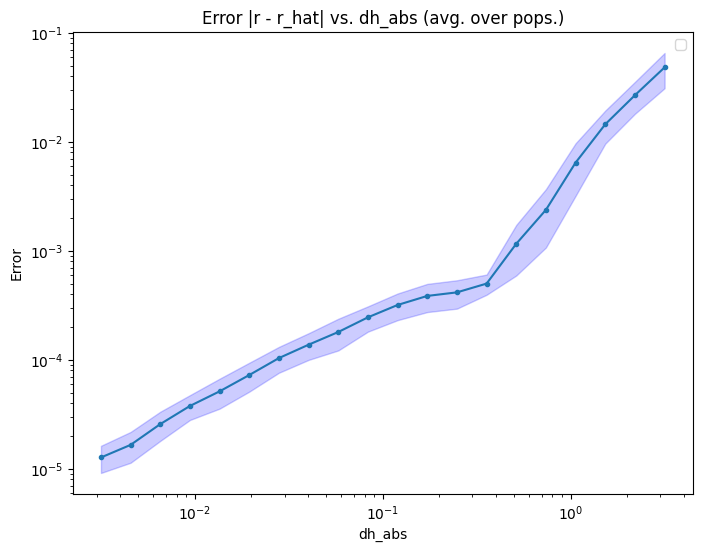

In [77]:
import matplotlib.pyplot as plt

# Compute error mean and std. over trials
err = np.abs(R - Rhat) / R
err = err.mean(dim='pop')
err_mean = err.mean(dim='trial')
err_std = err.std(dim='trial')

#pop_vis = 0

# Plot mean error as a function of dh_abs
plt.figure(figsize=(8, 6))
#err_mean_ = err_mean.isel(pop=pop_vis).values
#err_std_ = err_std.isel(pop=pop_vis).values
err_mean_ = err_mean.values
err_std_ = err_std.values
plt.plot(dh_abs_vals, err_mean_, '.-')
plt.fill_between(
    dh_abs_vals,
    err_mean_ - err_std_,
    err_mean_ + err_std_,
    color='blue',
    alpha=0.2
)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('dh_abs')
plt.ylabel('Error')
#plt.title(f'Error |r - r_hat| vs. dh_abs (pop={pop_vis})')
plt.title(f'Error |r - r_hat| vs. dh_abs (avg. over pops.)')
plt.legend()
#plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()